In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Descargar archivo desde GitHub
!wget https://github.com/adiacla/bigdata/raw/refs/heads/master/imagenesvgg16.zip

--2026-04-08 23:51:53--  https://github.com/adiacla/bigdata/raw/refs/heads/master/imagenesvgg16.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/imagenesvgg16.zip [following]
--2026-04-08 23:51:53--  https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/imagenesvgg16.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 191649 (187K) [application/zip]
Saving to: ‘imagenesvgg16.zip’

imagenesvgg16.zip   100%[===================>] 187.16K  --.-KB/s    in 0.02s   

2026-04-08 23:51:53 (11.7 MB/s) - ‘imagenesvgg16.zip’ saved [191649/191649]



In [3]:
# Descomprimir el archivo
!unzip imagenesvgg16.zip

Archive:  imagenesvgg16.zip
  inflating: bus.jpg                 
  inflating: perro.jpg               
  inflating: vaso.jpg                


In [4]:
# Descomprimir en una carpeta específica
!unzip imagenesvgg16.zip -d /content/drive/MyDrive/imagenes/

Archive:  imagenesvgg16.zip
  inflating: /content/drive/MyDrive/imagenes/bus.jpg  
  inflating: /content/drive/MyDrive/imagenes/perro.jpg  
  inflating: /content/drive/MyDrive/imagenes/vaso.jpg  


In [5]:
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np


In [6]:
modelo = DenseNet121(weights='imagenet', include_top=True)

33188688/33188688 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
modelo.summary()

Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 8,062,504 (30.76 MB)

 Trainable params: 7,978,856 (30.44 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [8]:
nuevas_imagenes = ['/content/perro.jpg', '/content/bus.jpg', '/content/vaso.jpg']

imagenesnuevas = np.array([
    preprocess_input(
        img_to_array(
            load_img(img, target_size=(224, 224))
        )
    )
    for img in nuevas_imagenes
])

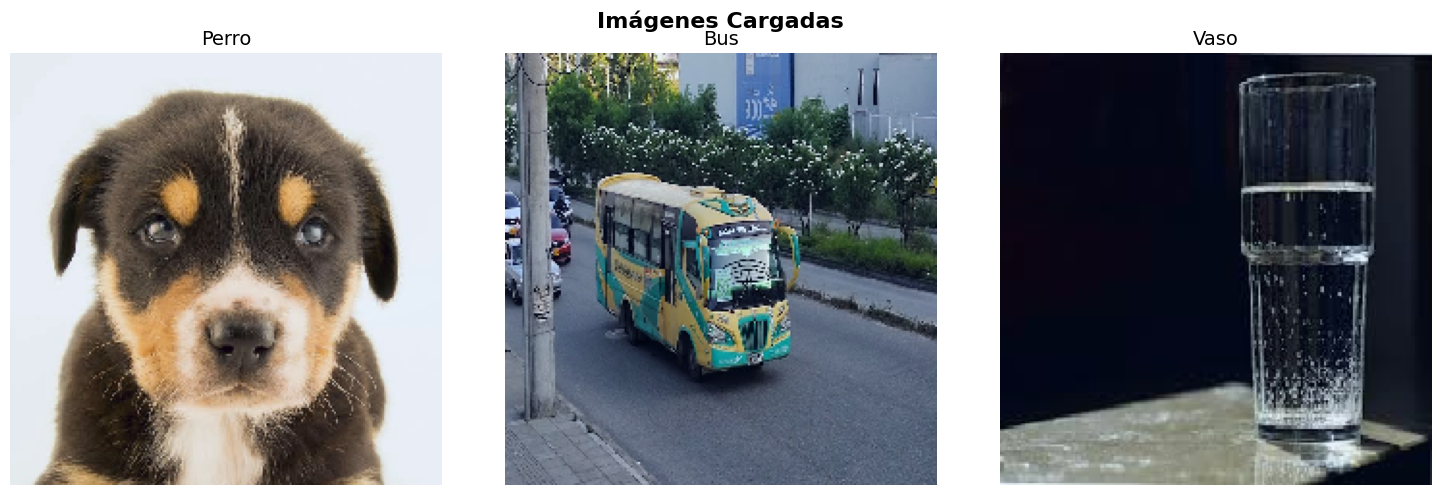

In [9]:
import matplotlib.pyplot as plt

nombres = ['Perro', 'Bus', 'Vaso']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, nombre) in enumerate(zip(axes, nombres)):
    # Desnormalizar la imagen para visualizarla correctamente
    img_mostrar = imagenesnuevas[i].copy()
    img_mostrar = img_mostrar - img_mostrar.min()
    img_mostrar = img_mostrar / img_mostrar.max()
    
    ax.imshow(img_mostrar)
    ax.set_title(nombre, fontsize=14)
    ax.axis('off')

plt.suptitle('Imágenes Cargadas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
predicciones = modelo.predict(imagenesnuevas)
resultados = decode_predictions(predicciones, top=3)

nombres = ['Perro', 'Bus', 'Vaso']

for nombre, resultado in zip(nombres, resultados):
    print(f"\n🖼️ Imagen: {nombre}")
    print("-" * 35)
    for i, (id_clase, descripcion, probabilidad) in enumerate(resultado):
        print(f"  Top {i+1}: {descripcion:<20} {probabilidad:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🖼️ Imagen: Perro
-----------------------------------
  Top 1: EntleBucher          34.36%
  Top 2: Appenzeller          28.38%
  Top 3: Greater_Swiss_Mountain_dog 23.51%

🖼️ Imagen: Bus
-----------------------------------
  Top 1: minibus              57.18%
  Top 2: trolleybus           25.08%
  Top 3: police_van           7.47%

🖼️ Imagen: Vaso
-----------------------------------
  Top 1: beer_glass           61.92%
  Top 2: cocktail_shaker      20.57%
  Top 3: oil_filter           2.39%


**Transfer Learning para perros y gatos**

In [11]:
import tensorflow as tf

In [12]:
import tensorflow as tf

# Descargar el dataset
dogs_cats = tf.keras.utils.get_file(
    'dogs_cats',
    origin='https://www.kaggle.com/api/v1/datasets/download/birajsth/cats-and-dogs-filtered',
    extract=True,
    
)

print(dogs_cats)

137363742/137363742 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
/root/.keras/datasets/dogs_cats


In [13]:
import os

# Ver qué hay en la ruta donde se descargó
base_dir = os.path.dirname(dogs_cats)
print("Ruta base:", base_dir)

# Listar archivos y carpetas
for ruta, carpetas, archivos in os.walk(base_dir):
    nivel = ruta.replace(base_dir, '').count(os.sep)
    sangria = ' ' * 2 * nivel
    print(f"{sangria}{os.path.basename(ruta)}/")
    if nivel < 3:  # Solo mostrar 3 niveles de profundidad
        for archivo in archivos:
            print(f"{sangria}  {archivo}")

Ruta base: /root/.keras/datasets
datasets/
  dogs_cats_archive
  dogs_cats/
    cats_and_dogs_filtered/
      vectorize.py
      validation/
        dogs/
        cats/
      cats_and_dogs_filtered/
        validation/
          dogs/
          cats/
        train/
          dogs/
          cats/
      train/
        dogs/
        cats/


In [14]:
base_dir = '/root/.keras/datasets/dogs_cats/cats_and_dogs_filtered'

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'validation')

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32
)

print(train_data.class_names)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
['cats', 'dogs']


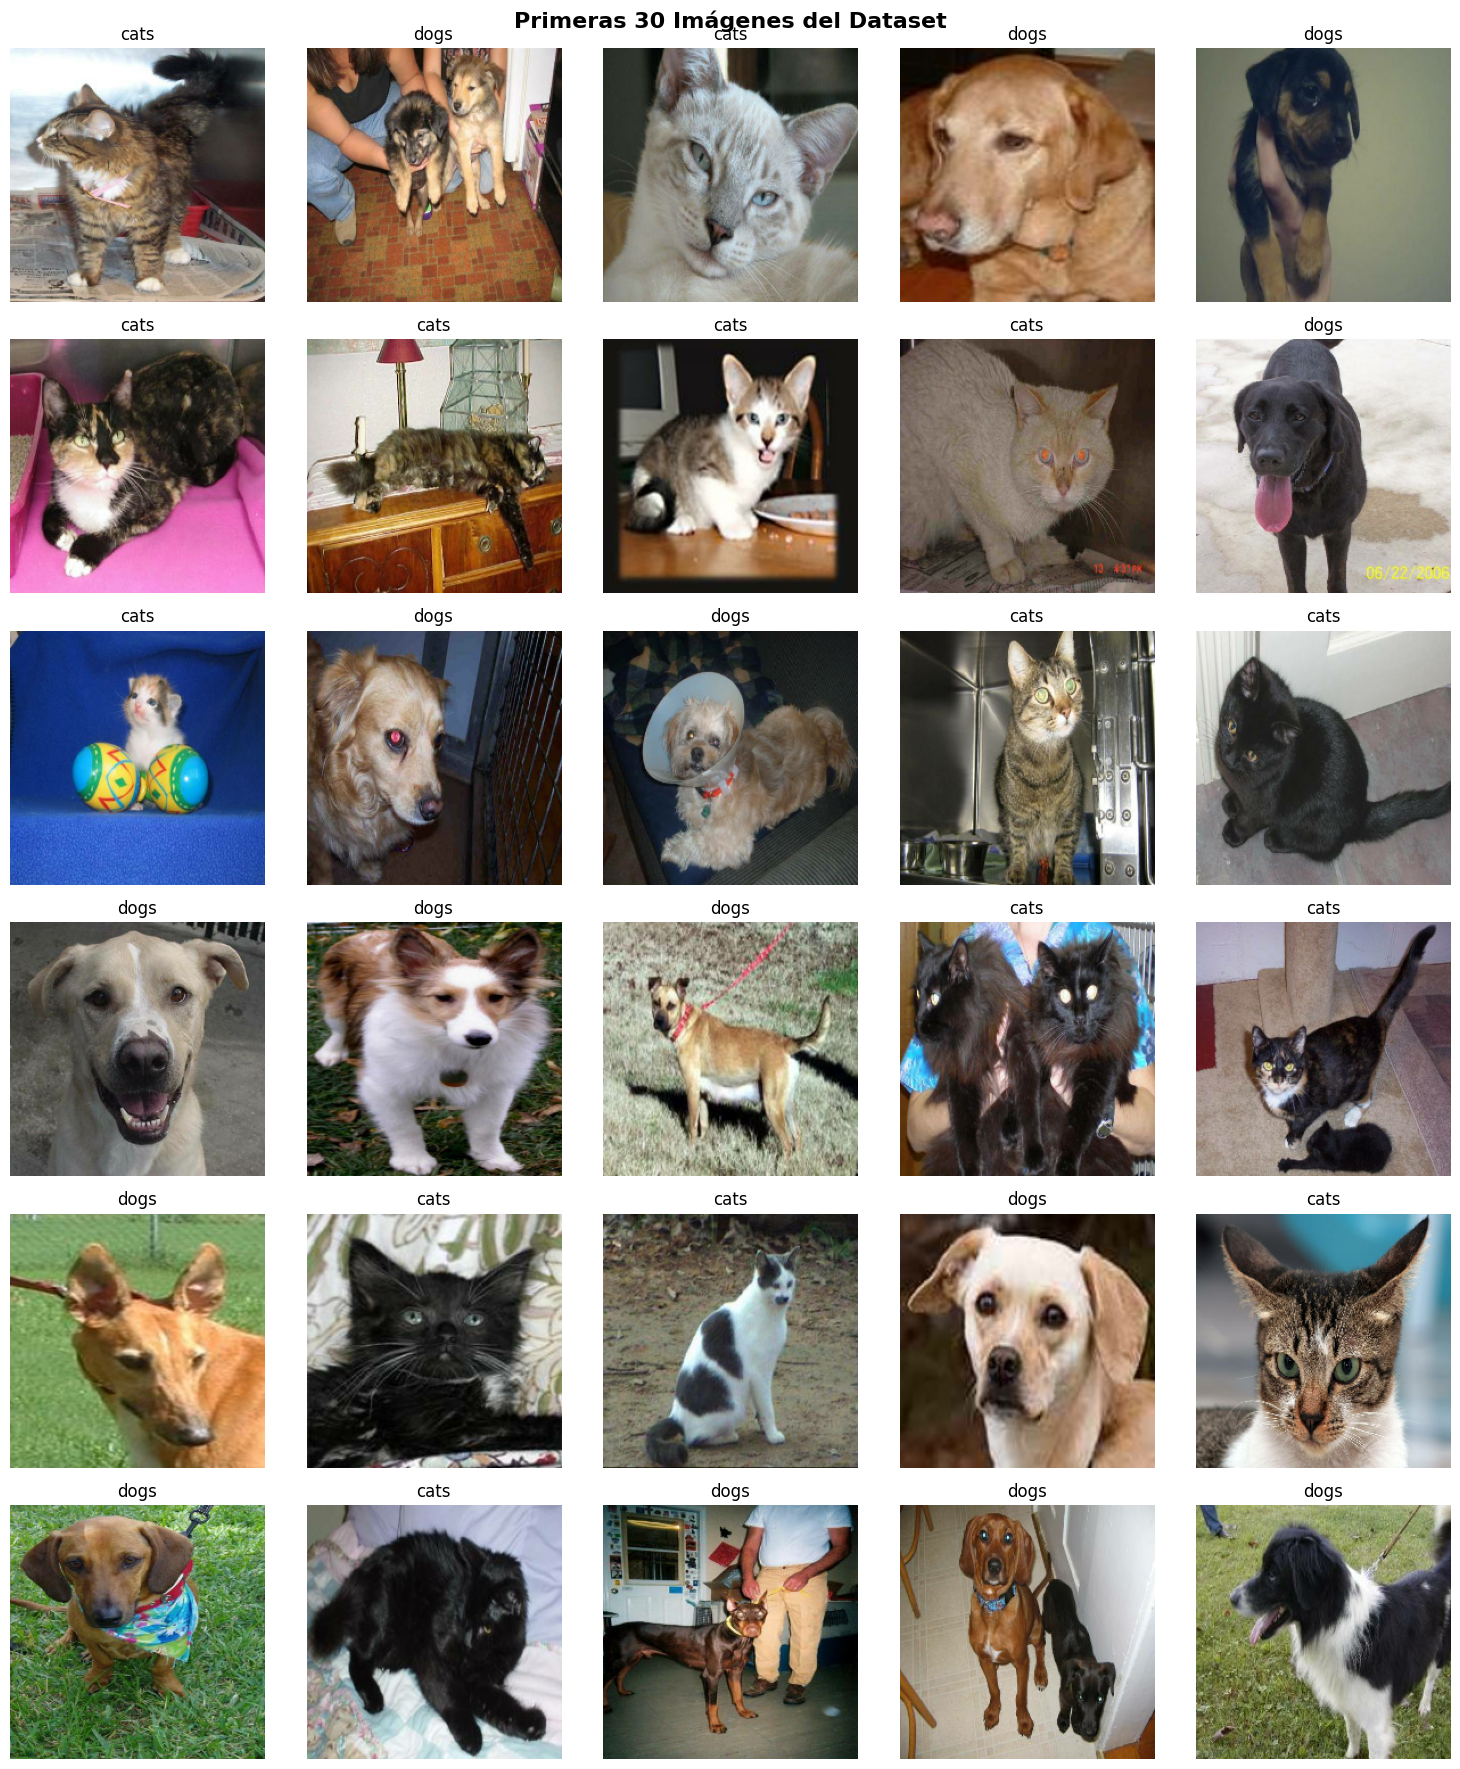

In [15]:
import matplotlib.pyplot as plt

nombres_clases = train_data.class_names

fig, axes = plt.subplots(6, 5, figsize=(15, 18))
axes = axes.flatten()

contador = 0
for imagenes, etiquetas in train_data:
    for i in range(len(imagenes)):
        if contador >= 30:
            break
        axes[contador].imshow(imagenes[i].numpy().astype('uint8'))
        axes[contador].set_title(nombres_clases[etiquetas[i]], fontsize=12)
        axes[contador].axis('off')
        contador += 1
    if contador >= 30:
        break

plt.suptitle('Primeras 30 Imágenes del Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
import tensorflow as tf

# 1. Averiguamos cuántos lotes (batches) totales tiene el dataset de validación
val_batches = tf.data.experimental.cardinality(val_data)

# 2. Calculamos el 20% de esos lotes (dividiendo entre 5)
test_batches = val_batches // 5

# 3. Creamos el de Prueba (test) tomando ese primer 20%
test_data = val_data.take(test_batches)

# 4. Actualizamos el de Validación saltándonos ese 20% usado, dejando el 80% restante
val_data = val_data.skip(test_batches)

# --- Verificación ---
# Imprimimos la cantidad de lotes finales que quedaron en cada lado
print(f"Lotes en test (20%): {tf.data.experimental.cardinality(test_data).numpy()}")
print(f"Lotes en validación (80%): {tf.data.experimental.cardinality(val_data).numpy()}")



Lotes en test (20%): 6
Lotes en validación (80%): 26


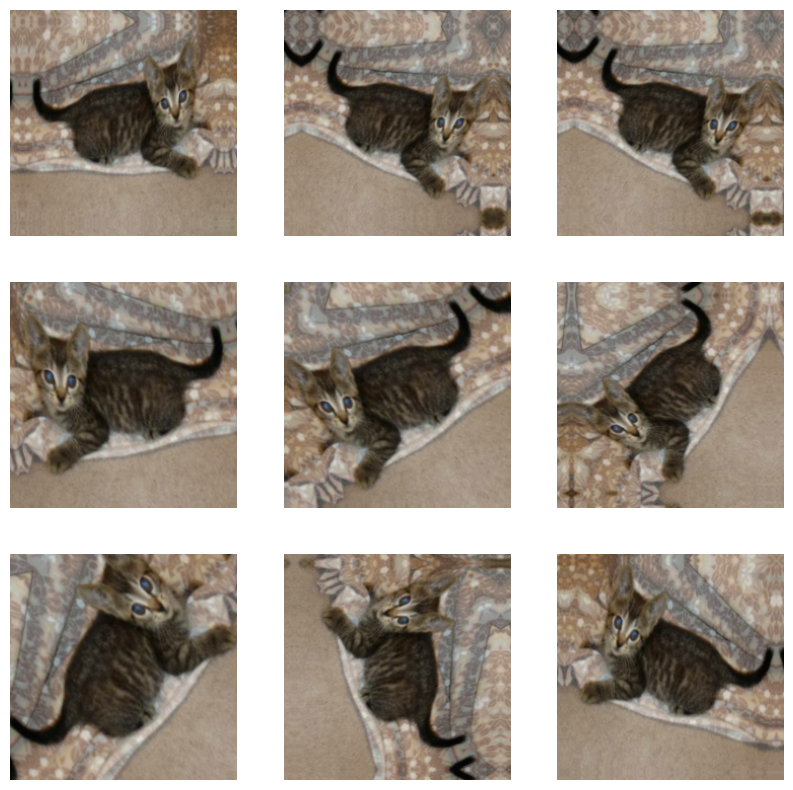

In [18]:
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Creamos nuestro bloque de Data Augmentation con las transformaciones deseadas
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"), # Voltear horizontalmente
  tf.keras.layers.RandomRotation(0.2),      # Rotar ligeramente
  tf.keras.layers.RandomZoom(0.2),          # Acercar y alejar la imagen
])

# 2. Tomamos el primer lote de imágenes (batch) del dataset de entrenamiento
for images, labels in train_data.take(1):
    
    # Extraemos la primerísima imagen de ese lote
    first_image = images[0]
    
    plt.figure(figsize=(10, 10))
    
    # 3. Le vamos a aplicar la aumentación 9 veces distintas a la MISMA imagen
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # training=True es sumamente importante para que las capas de aumento 
        # se activen (hagan simulaciones aleatorias)
        augmented_image = data_augmentation(tf.expand_dims(first_image, axis=0), training=True)
        
        # Convertimos la imagen de vuelta a tipo entero 'uint8' (0 a 255) para poder imprimirla en matplotlib
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")
        
plt.show() # Mostrar gráfico final


In [19]:
# 1. Construimos la base del modelo
preprocess_input = tf.keras.applications.densenet.preprocess_input

# 2. Definimos nuestras entradas
inputs = tf.keras.Input(shape=(224, 224, 3))

# 3. Paso de Aumentación de datos (el bloque de la celda que hicimos antes)
x = data_augmentation(inputs)

# 4. Paso de Preprocesamiento EXACTO para DenseNet121
x = preprocess_input(x)

# --- De aquí en adelante agregas el modelo pre-entrenado normal ---
# base_model = tf.keras.applications.DenseNet121(include_top=False, weights='imagenet')
# base_model.trainable = False # Congelar pesos
# x = base_model(x, training=False)


In [20]:
# 1. Indicamos la forma de nuestras imágenes (224x224 píxeles a color RGB)
IMG_SHAPE = (224, 224, 3)

# 2. Instanciamos el modelo base
base_model = tf.keras.applications.DenseNet121(
    input_shape=IMG_SHAPE,
    include_top=False,  # MUY IMPORTANTE: Excluye la capa clasificadora original
    weights='imagenet'  # Usa los pesos de años de entrenamiento previo
)

# 3. Congelamos (freeze) la capa base
# Esto evitará que los valiosos patrones que DenseNet ya aprendió
# se modifiquen o destruyan accidentalmente durante el entrenamiento inicial.
base_model.trainable = False

# 4. Imprime para ver la estructura (opcional)
print("Arquitectura base cargada. N° de capas en el modelo base: ", len(base_model.layers))

# Puedes descomentar la siguiente línea si quieres ver todo el resumen 
# base_model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Arquitectura base cargada. N° de capas en el modelo base:  427


In [21]:
# 1. Congelar la base convolucional
base_model.trainable = False

# 2. Comprobación (Verificación)
# Si imprimimos la cantidad de capas/variables que se pueden entrenar en la base, debe darnos cero (0).
print("Variables entrenables (trainable variables) en el modelo base:", len(base_model.trainable_variables))


Variables entrenables (trainable variables) en el modelo base: 0


In [22]:
base_model.summary()


Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,037,504 (26.85 MB)

In [23]:
import tensorflow as tf

# Definimos la capa principal de entrada
inputs = tf.keras.Input(shape=(224, 224, 3))

# 1. Aumentación de datos (las modificaciones aleatorias a la imagen)
x = data_augmentation(inputs)

# 2. Preprocesamiento (Ajustamos los colores al estándar de DenseNet)
x = tf.keras.applications.densenet.preprocess_input(x)

# 3. Modelo base (nuestra red experta en extraer características)
# training=False es para que Keras mantenga las capas internas (Batch Normalization) sin cambios.
x = base_model(x, training=False)

# 4. Promedio de las características extraídas 
# (Convierte los mapas de 2D en un solo vector simplificado)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# 5. Dropout del 20% (Apaga canales aleatoriamente para evitar sobrememorización/overfitting)
x = tf.keras.layers.Dropout(0.2)(x)

# 6. Salida para las 2 clases
# Como es una clasificación binaria (Perro = 0 o Gato = 1), usamos una (1) sola neurona de salida.
outputs = tf.keras.layers.Dense(1)(x)

# --- ENSAMBLADO FINAL ---
# Creamos el nuevo modelo que une el input con todo el flujo hasta el output
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Volvemos a mirar el resumen, pero esta vez de nuestro modelo completo
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [24]:
import tensorflow as tf

# 1. Compilación del Modelo
# (Si ya lo compilaste antes en tus apuntes, igual puedes sobreescribirlo aquí sin problema)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    # from_logits=True es necesario porque nuestra capa Dense(1) no usó una activación 'sigmoid'
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 2. Iniciar el Entrenamiento y capturar el "History"
epocas = 20

print("⏳ Iniciando entrenamiento. Por favor espera...")

history = model.fit(
    train_data,                 # Las imágenes a estudiar (entrenamiento)
    epochs=epocas,              # Se enseñará a lo largo de 20 ciclos 
    validation_data=val_data    # Verificará la precisión contra el 80% que dejamos para validación
)

print("✅ ¡Entrenamiento completado!")


⏳ Iniciando entrenamiento. Por favor espera...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 334ms/step - accuracy: 0.5515 - loss: 0.7601 - val_accuracy: 0.6200 - val_loss: 0.6265
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - accuracy: 0.6505 - loss: 0.6217 - val_accuracy: 0.7240 - val_loss: 0.5031
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - accuracy: 0.7125 - loss: 0.5287 - val_accuracy: 0.8119 - val_loss: 0.3988
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 213ms/step - accuracy: 0.7865 - loss: 0.4514 - val_accuracy: 0.8738 - val_loss: 0.3263
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - accuracy: 0.8135 - loss: 0.4081 - val_accuracy: 0.9047 - val_loss: 0.2807
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - accuracy: 0.8495 - loss: 0.3546 - val_accuracy: 0.9257 - val_loss: 0.2367
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step - accuracy: 0.8755 - loss: 0.3177 - val_accuracy: 0.9394 - val_loss: 0.2118
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/st

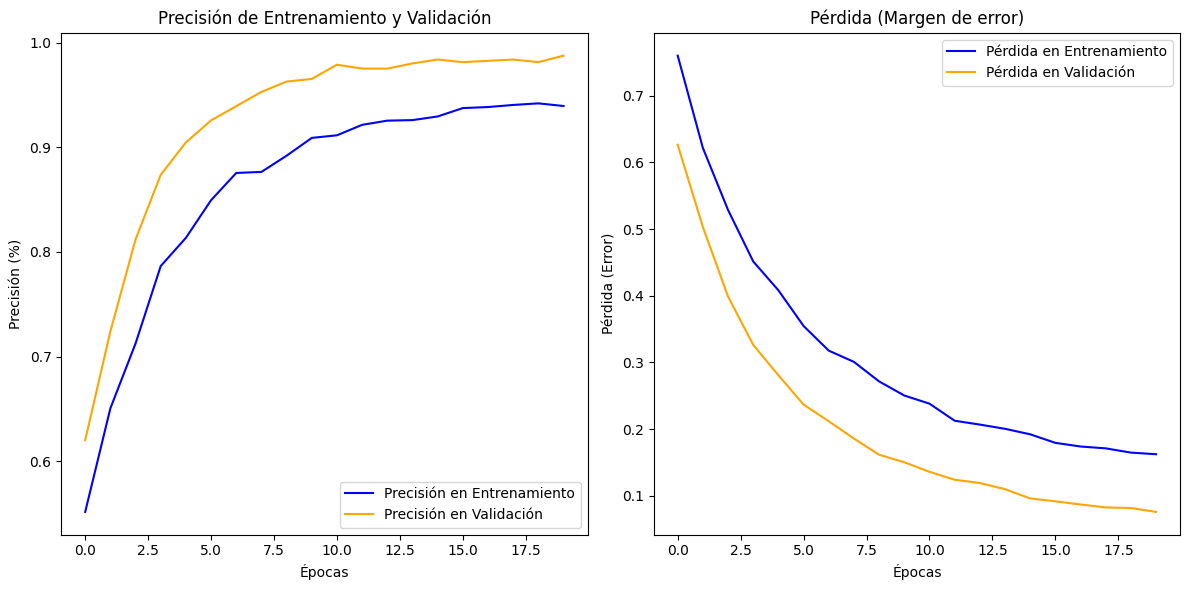

In [25]:
import matplotlib.pyplot as plt

# 1. Extraemos los arreglos con los datos almacenados
# (si te lanza error de llave, intenta cambiar 'accuracy' por 'acc')
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Rango dinámico por la cantidad de épocas
epocas_rango = range(len(acc))

plt.figure(figsize=(12, 6))

# --- GRÁFICA 1: PRECISIÓN (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(epocas_rango, acc, label='Precisión en Entrenamiento', color='blue')
plt.plot(epocas_rango, val_acc, label='Precisión en Validación', color='orange')
plt.legend(loc='lower right')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión (%)')

# --- GRÁFICA 2: PÉRDIDA (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(epocas_rango, loss, label='Pérdida en Entrenamiento', color='blue')
plt.plot(epocas_rango, val_loss, label='Pérdida en Validación', color='orange')
plt.legend(loc='upper right')
plt.title('Pérdida (Margen de error)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Error)')

plt.tight_layout()
plt.show()


In [3]:
print("Evaluando el modelo con los datos de Prueba (Test Data)...")

# 'evaluate' devuelve dos valores: el error (loss) y la precisión (accuracy)
loss, accuracy = model.evaluate(test_data)

print(f"Precisión Exacta: {accuracy * 100:.2f}%")



Evaluando el modelo con los datos de Prueba (Test Data)...


NameError: name 'model' is not defined